# Decimation Double-Parameterization Pipeline

**Strategy**: Decimate the original mesh to M_dec, map M_dec **directly** to the
sphere (no segmentation, no fan mesh, no patches), then interpolate the removed
fine-mesh vertices back onto the sphere using barycentric coordinates.

### Pipeline overview

1. Load original mesh **M** (2002 verts, 4000 faces)
2. Decimate to **M_dec** (~500 verts, ~1000 faces) using topology-preserving VTK decimation
3. Record vertex mapping: which original vertices survived
4. **Map M_dec directly to sphere** via `map2sphere` (Brechbuhler heat-diffusion bijective mapping)
5. Optimize M_dec parameterization on the sphere (area/edge-length Newton steps)
6. **Second pass**: interpolate (theta, phi) for removed fine-mesh vertices via barycentric coordinates
7. Build full fine-mesh spherical parameterization
8. SHP projection

This avoids all segmentation/fan-mesh/patch issues because `map2sphere` works
on any closed genus-0 manifold mesh.

## 1. Imports and boiler-plate

In [1]:
import numpy as np
import sys
import os

code_dir = r'C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

from pySHP.surface_mesh import surface_mesh
from pySHP.shp_surface import shp_surface
from pySHP.utils import readoff

import pyvista as pv
pv.set_jupyter_backend('static')
print('PyVista: static backend')

PyVista: static backend


## 2. Load original fine mesh

In [2]:
topic = 'test_set'
file_name = 'mushroom_repaired_03.off'
fn_shape = os.path.join(code_dir,
    'Matlab', 'shp_toolbox-main', 'shp_toolbox-main', 'test_data', 'off',
    topic, file_name)
X_orig, F_orig = readoff(fn_shape)
m_orig = surface_mesh(X_orig, F_orig)
m_orig.disp()
print(f'Original mesh: {len(m_orig.X)} vertices, {len(m_orig.F)} faces')

Mesh Information
Vertices:            2002
Faces:               4000
Edges:               6000
--------------------------------------------------
Euler characteristic: 2  (V - E + F)
Genus:               0  (0=sphere, 1=torus, ...)
--------------------------------------------------
Is closed:           True
Is manifold:         True
Boundary edges:      0
Boundary loops:      0
Connected components: 1
Area:                6.58707
Volume:              0.849632
Original mesh: 2002 vertices, 4000 faces


## 3. Repair original mesh

In [3]:
m_orig.repair_mesh()
components = m_orig.find_disconnected_surfaces()
m_orig.keep_largest_surface()
m_orig.info()
m_orig.check_mesh_integrity()
m_orig.print_mesh_quality()

Starting mesh repair sequence...
Initial mesh: 2002 vertices, 4000 faces
Removing duplicate vertices and faces...
  No duplicate vertices or faces found
Mesh repair complete: 2002 vertices, 4000 faces
Removing isolated vertices...
  No isolated vertices found
Mesh repair complete: 2002 vertices, 4000 faces
Performing deep mesh cleaning...

Mesh connectivity: Single connected component (4000 faces)

------------------------------------------------------------
Checking and fixing normal/winding consistency...
------------------------------------------------------------
Fixing normal/winding consistency...
  Fixed 26 flipped faces (normals now point consistently outward)
Mesh repair complete: 2002 vertices, 4000 faces

Mesh repair complete!
Final mesh: 2002 vertices, 4000 faces
Mesh appears to be a closed shape (Euler characteristic = 2)
Found 1 disconnected surface components
  Component 0: 4000 faces
Mesh is already a single connected component
Mesh Information
Vertices:            2002

{'n_vertices': 2002,
 'n_faces': 4000,
 'n_edges': 6000,
 'mean_edge_length': np.float64(0.0634560399529037),
 'std_edge_length': np.float64(0.012303819333131471),
 'mean_quality': np.float64(0.9139325959552537),
 'min_quality': np.float64(0.4195223033530878),
 'mean_area': np.float64(0.0016467683573388292),
 'std_area': np.float64(0.00042023418449325337),
 'area_uniformity': np.float64(0.2551871868441473)}

## 4. Decimate to M_dec

Use topology-preserving VTK decimation (`decimate_pro`).  This guarantees the
result is manifold, closed, and genus-0 (same topology as input).

We record `vert_map_dec` so we can later interpolate the removed vertices.

In [4]:
target_faces_dec = 3000

X_fine = np.array(m_orig.X, dtype=float).copy()
F_fine = np.array(m_orig.F, dtype=int).copy()
n_fine_verts = len(X_fine)
n_fine_faces = len(F_fine)

n_current = len(F_fine)
target_reduction = 1.0 - target_faces_dec / n_current
target_reduction = min(max(target_reduction, 0.0), 0.99)

faces_pv = np.hstack([np.full((n_current, 1), 3, dtype=int), F_fine]).ravel()
mesh_pv = pv.PolyData(X_fine, faces_pv)
mesh_dec_pv = mesh_pv.decimate_pro(
    target_reduction, preserve_topology=True, feature_angle=30.0)

X_dec = np.array(mesh_dec_pv.points)
F_dec = np.array(mesh_dec_pv.faces.reshape(-1, 4)[:, 1:4])

print(f'Decimated mesh: {len(X_dec)} vertices, {len(F_dec)} faces')
print(f'Reduction: {n_fine_faces} -> {len(F_dec)} faces '
      f'({100*(1 - len(F_dec)/n_fine_faces):.1f}% removed)')

# Build vertex map: decimated vertex index -> original fine-mesh vertex index
from scipy.spatial import cKDTree
tree_fine = cKDTree(X_fine)
dists, vert_map_dec = tree_fine.query(X_dec)

n_exact = np.sum(dists < 1e-12)
print(f'Vertex mapping: {n_exact}/{len(X_dec)} matched exactly '
      f'(max dist = {dists.max():.2e})')

survived_set = set(vert_map_dec)
removed_verts = np.array([i for i in range(n_fine_verts) if i not in survived_set])
print(f'Survived: {len(survived_set)}, Removed: {len(removed_verts)}')

m_dec = surface_mesh(X_dec, F_dec)
m_dec.disp()

Decimated mesh: 1502 vertices, 3000 faces
Reduction: 4000 -> 3000 faces (25.0% removed)
Vertex mapping: 1502/1502 matched exactly (max dist = 0.00e+00)
Survived: 1502, Removed: 500
Mesh Information
Vertices:            1502
Faces:               3000
Edges:               4500
--------------------------------------------------
Euler characteristic: 2  (V - E + F)
Genus:               0  (0=sphere, 1=torus, ...)
--------------------------------------------------
Is closed:           True
Is manifold:         True
Boundary edges:      0
Boundary loops:      0
Connected components: 1
Area:                6.59027
Volume:              0.850121


{'n_vertices': 1502,
 'n_faces': 3000,
 'n_edges': 4500,
 'euler_characteristic': 2,
 'genus': 0,
 'is_closed': True,
 'is_manifold': True,
 'n_boundary_edges': 0,
 'n_boundary_loops': 0,
 'n_components': 1}

## 5. Verify M_dec topology

Confirm that M_dec is manifold, closed, genus-0 before mapping to the sphere.

In [5]:
m_dec.info()
m_dec.check_mesh_integrity()
m_dec.print_mesh_quality()

Mesh Information
Vertices:            1502
Faces:               3000
Edges:               4500
--------------------------------------------------
Euler characteristic: 2  (V - E + F)
Genus:               0  (0=sphere, 1=torus, ...)
--------------------------------------------------
Is closed:           True
Is manifold:         True
Boundary edges:      0
Boundary loops:      0
Connected components: 1
Mesh integrity check passed (no issues found)
Mesh Quality Statistics
Vertices:           1502
Faces:              3000
Edges:              4500
Mean edge length:   0.0735
Std edge length:    0.0332
Mean quality:       0.8671
Min quality:        0.0141
Mean face area:     0.002197
Area uniformity:    0.9465 (lower is better)


{'n_vertices': 1502,
 'n_faces': 3000,
 'n_edges': 4500,
 'mean_edge_length': np.float64(0.07353616870429877),
 'std_edge_length': np.float64(0.0331719957345696),
 'mean_quality': np.float64(0.8670657130379731),
 'min_quality': np.float64(0.0141162166122242),
 'mean_area': np.float64(0.002196758012360967),
 'std_area': np.float64(0.00207928510502062),
 'area_uniformity': np.float64(0.9465244206784101)}

## 6. Map M_dec directly to sphere (bijective mapping)

No segmentation needed. `map2sphere` uses the Brechbuhler heat-diffusion method
which works on any closed genus-0 manifold mesh.  The result gives (theta, phi)
for every vertex of M_dec.

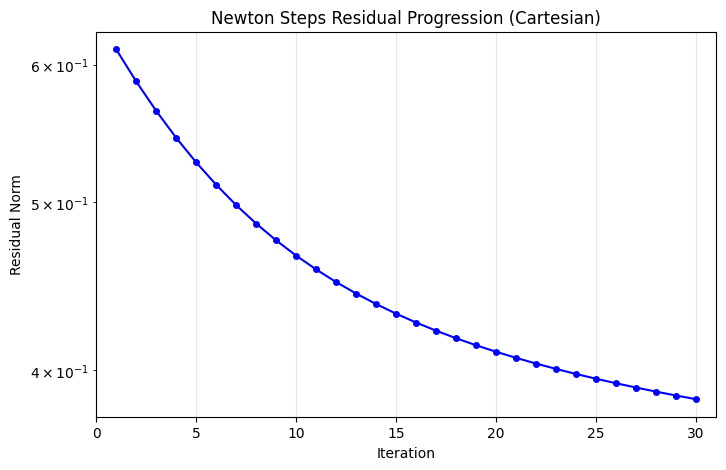

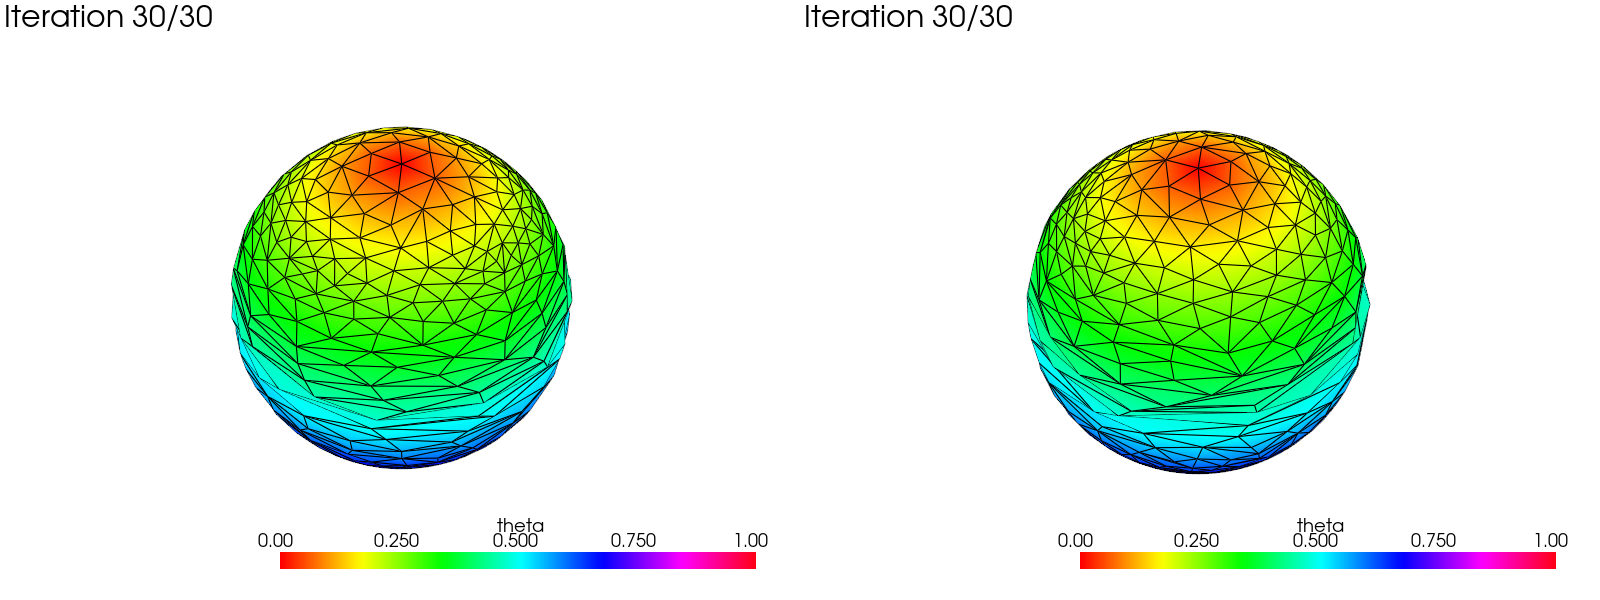

Iteration 30/30: Residual norm = 3.850119e-01


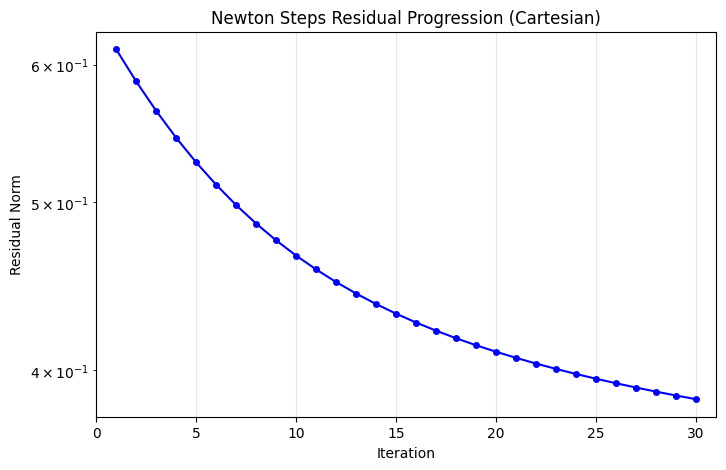

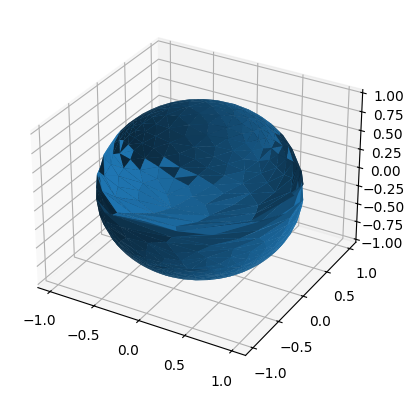

Sphere orientation: 215 CCW, 2785 CW out of 3000 faces
  -> Mirrored parameterization detected. Flipping phi to fix.
  -> After flip: 2785 CCW out of 3000 faces


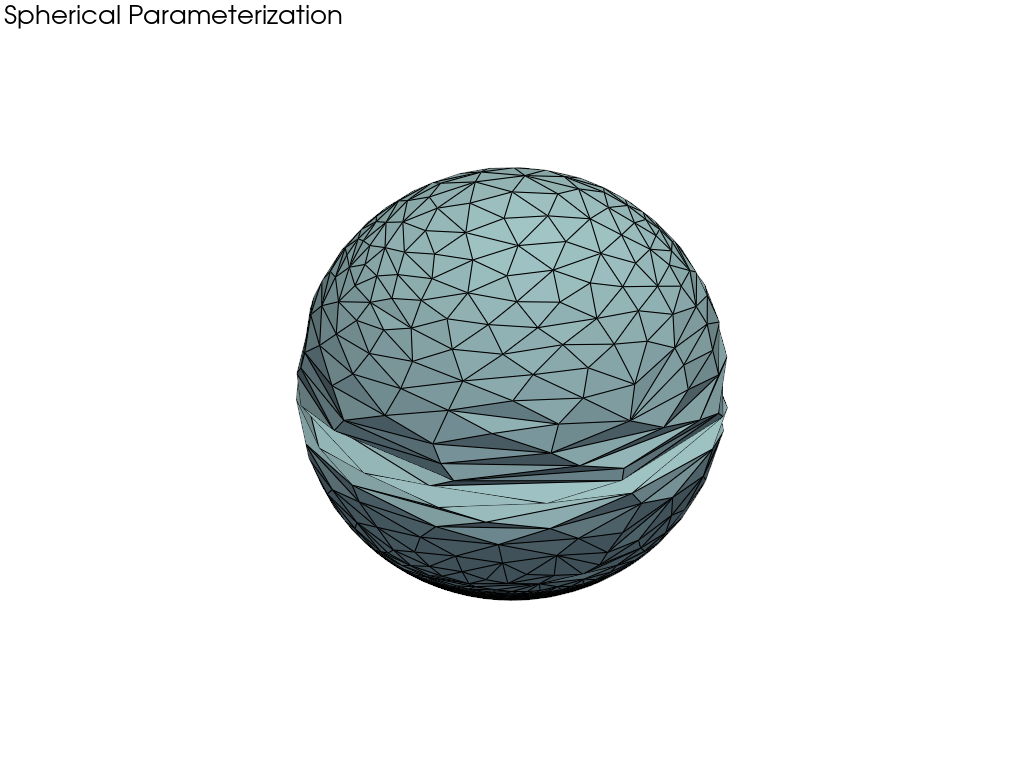

In [6]:
m_dec.needs_mesh2sphere = 1
m_dec.optimization_method = 1   # area Newton steps
m_dec.newton_niter = 30
m_dec.newton_step = 0.1
m_dec.newton_step_edge = 0.05
m_dec.bijective_plot_flag = 2
m_dec.map2sphere()

# Check if the bijective mapping produced a mirrored parameterization.
# If the majority of faces are CW on the sphere, flip phi to mirror it.
from pySHP.utils import kk_sph2cart
_u, _v, _w = kk_sph2cart(m_dec.t, m_dec.p, np.ones(len(m_dec.t)))
_Xs = np.column_stack([_u, _v, _w])
_n_pos = 0
_n_neg = 0
for _fi in range(len(m_dec.F)):
    _orient = np.dot(_Xs[m_dec.F[_fi, 0]], np.cross(_Xs[m_dec.F[_fi, 1]], _Xs[m_dec.F[_fi, 2]]))
    if _orient > 0:
        _n_pos += 1
    elif _orient < 0:
        _n_neg += 1

print(f'Sphere orientation: {_n_pos} CCW, {_n_neg} CW out of {len(m_dec.F)} faces')
if _n_neg > _n_pos:
    print(f'  -> Mirrored parameterization detected. Flipping phi to fix.')
    m_dec.p = (2 * np.pi - m_dec.p) % (2 * np.pi)
    # Verify
    _u2, _v2, _w2 = kk_sph2cart(m_dec.t, m_dec.p, np.ones(len(m_dec.t)))
    _Xs2 = np.column_stack([_u2, _v2, _w2])
    _n_pos2 = sum(1 for _fi in range(len(m_dec.F))
                  if np.dot(_Xs2[m_dec.F[_fi, 0]], np.cross(_Xs2[m_dec.F[_fi, 1]], _Xs2[m_dec.F[_fi, 2]])) > 0)
    print(f'  -> After flip: {_n_pos2} CCW out of {len(m_dec.F)} faces')
else:
    print(f'  -> Parameterization is correctly oriented (no flip needed).')

# Fix any remaining inward-facing faces (fix at spherical parameterization stage)
from pySHP.level1.fix_flipped_faces import fix_spherical_parameterization_normals, check_spherical_parameterization_normals
m_dec, _ = fix_spherical_parameterization_normals(m_dec, verbose=True)
_ = check_spherical_parameterization_normals(m_dec, verbose=True)

m_dec.plot_spherical_parameterization()

## 7. Post-mapping diagnostic

In [7]:
import importlib, sys as _sys
_mod = 'pySHP.level1.diagnose_spherical_parameterization'
if _mod in _sys.modules:
    importlib.reload(_sys.modules[_mod])
from pySHP.level1.diagnose_spherical_parameterization import diagnose_spherical_parameterization

diag_file = os.path.join(code_dir, 'pySHP', 'tests', 'ddp_sphere_diagnostic.txt')
sph_report = diagnose_spherical_parameterization(m_dec, verbose=True, output_file=diag_file)
print(f'\nDiagnostic written to: {diag_file}')
if sph_report['valid']:
    print('Spherical parameterization looks GOOD.')
else:
    print('Spherical parameterization has ISSUES -- review diagnostic.')

SPHERICAL PARAMETERIZATION DIAGNOSTIC  |  2026-02-25 11:57:16
  Mesh: 1502 vertices, 3000 faces

--- Poles ---
  North pole (ixN=136): X=[-0.0504 -0.8858 -0.0516], theta=0.000000, phi=0.000000
  South pole (ixS=505): X=[ 0.2754  0.3375 -0.1597], theta=3.141593, phi=0.000000

--- Theta (latitude) statistics ---
  Range: [0.000000, 3.141593]  (expect [0, pi])
  Mean: 2.013391,  Std: 0.540974
  Vertices at theta~0 (north): 1
  Vertices at theta~pi (south): 1

--- Phi (longitude) statistics ---
  Range: [0.000000, 6.279417]  (expect [0, 2*pi])
  Mean: 2.811064,  Std: 1.957399
  Vertices at phi~0: 2

--- Theta histogram (10 equal bins over [0, pi]) ---
  [0.000, 0.314):    7  #######
  [0.314, 0.628):   44  ############################################
  [0.628, 0.942):   93  ############################################################
  [0.942, 1.257):   57  #########################################################
  [1.257, 1.571):   52  ####################################################

## 8. Optimize M_dec parameterization on sphere

Run area/shear and then shear-only Newton steps to improve the mapping quality.

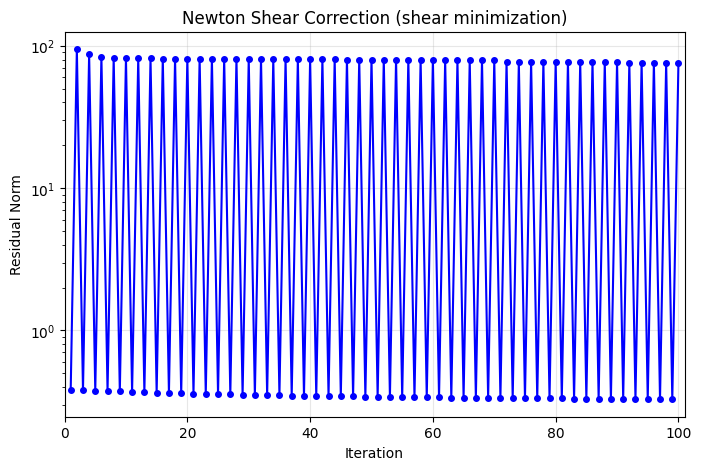

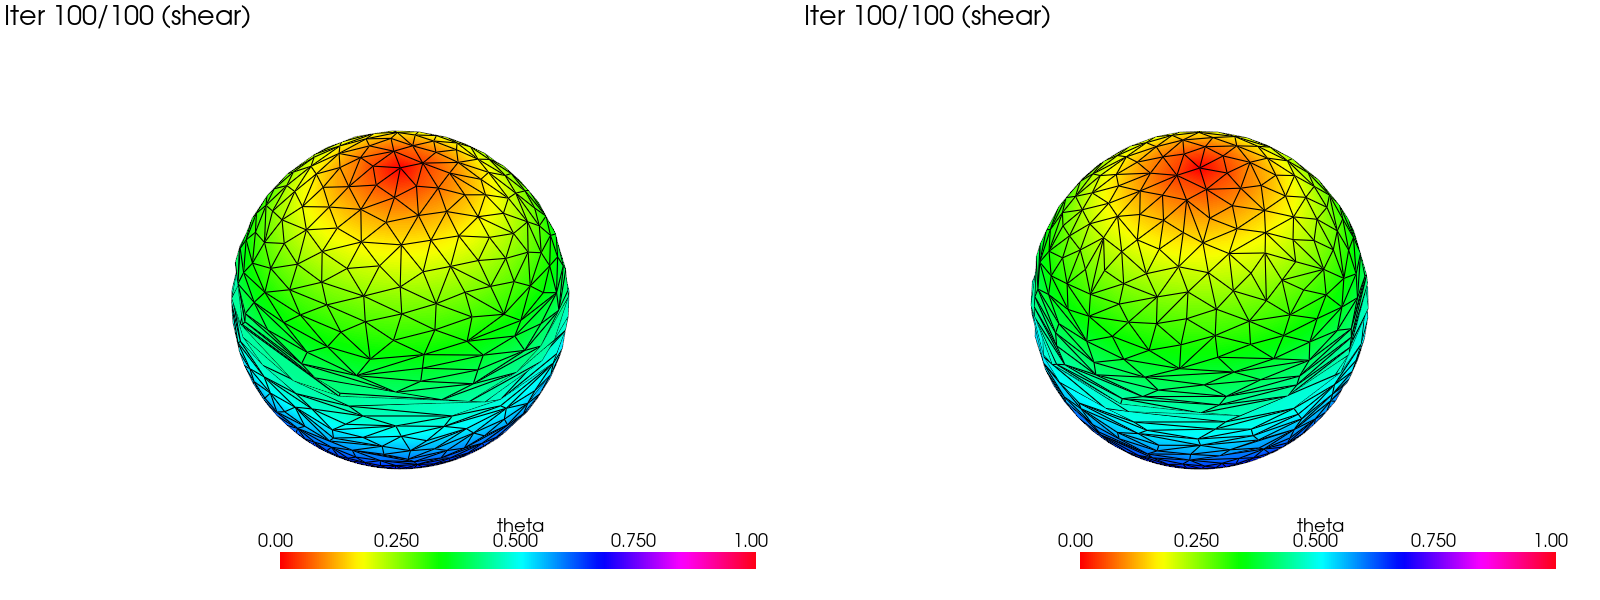

Iteration 100/100: Residual norm = 7.609318e+01 (shear)


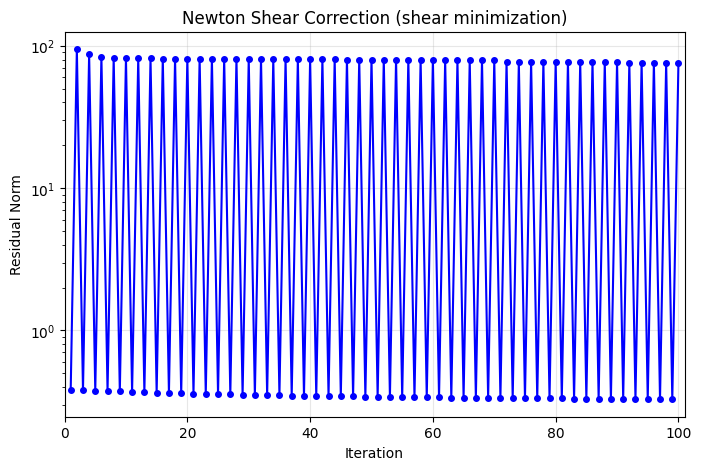

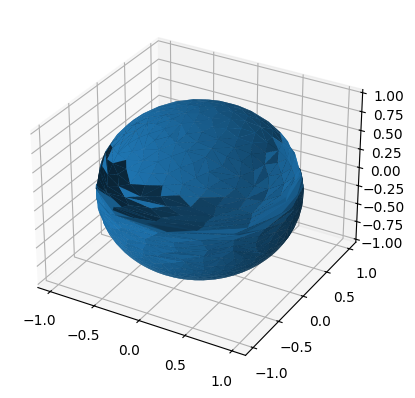


--- Full parameterized mesh: spherical normals check ---
  Faces checked (all vertices parameterized): 2994 / 3000
  Faces skipped (missing t,p): 6
  Outward (orient > 0): 2779
  Inward (orient < 0):  215
  Degenerate (|orient| < 1e-08): 0
  >>> INCONSISTENT: some normals inward, some outward (or degenerate).
      Spherical parameterization optimization / spherical harmonics may be invalid.
      Flipped face indices (first 20): [155, 161, 318, 323, 382, 383, 384, 386, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 404, 532] ...
---


M_dec optimized: 1502 verts, theta=[0.0000, 3.1416]


In [8]:
# Area/shear optimization
m_dec.optimization_method = 2
m_dec.prevent_flip = True
m_dec.newton_niter = 100
m_dec.newton_step = 0.2
m_dec.map2sphere()
m_dec.needs_map2sphere = 0

# Fix any inward-facing faces (optimization can introduce new flips)
from pySHP.level1.fix_flipped_faces import fix_spherical_parameterization_normals, check_spherical_parameterization_normals
m_dec, _ = fix_spherical_parameterization_normals(m_dec, verbose=True)
_ = check_spherical_parameterization_normals(m_dec, verbose=True)

print(f'\nM_dec optimized: {len(m_dec.X)} verts, '
      f'theta=[{m_dec.t.min():.4f}, {m_dec.t.max():.4f}]')

## 9. Visualize M_dec on sphere

In [9]:
html_dir = os.path.join(code_dir, 'pySHP', 'tests', 'ddp_html')
os.makedirs(html_dir, exist_ok=True)
html_path = os.path.join(html_dir, 'mdec_on_sphere.html')

m_dec.plot_spherical_parameterization(flag=0, export_html_path=html_path)
print(f'Exported: {html_path}')

Exported full parameterization on sphere to: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\mdec_on_sphere.html
Exported: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\mdec_on_sphere.html


## 10. Second pass: interpolate fine-mesh vertices onto sphere

For each original fine-mesh vertex that was removed during decimation,
find its enclosing triangle in M_dec and interpolate (theta, phi) via
barycentric coordinates.  Vertices that survived decimation get their
(theta, phi) copied directly.

In [10]:
from pySHP.level1.interpolate_fine_mesh_from_decimated import (
    interpolate_fine_mesh_parameterization
)

t_full, p_full, interp_report = interpolate_fine_mesh_parameterization(
    X_fine, F_fine,
    X_dec, F_dec, m_dec.t, m_dec.p,
    vert_map_dec,
    verbose=True
)

print(f'\nInterpolation results:')
print(f'  Total fine-mesh vertices: {n_fine_verts}')
print(f'  Survived (direct copy):   {interp_report["n_survived"]}')
print(f'  Interpolated:             {interp_report["n_interpolated"]}')
print(f'  Failed (nearest fallback):{interp_report["n_failed"]}')
print(f'  Theta range: [{t_full.min():.4f}, {t_full.max():.4f}]')
print(f'  Phi range:   [{p_full.min():.4f}, {p_full.max():.4f}]')

Survived vertices (direct copy): 1502
Vertices to interpolate: 500
  Processed 500/500 vertices (500 interpolated, 0 fallback)
Interpolation complete: 500 interpolated, 0 fallback (nearest vertex)

Interpolation results:
  Total fine-mesh vertices: 2002
  Survived (direct copy):   1502
  Interpolated:             500
  Failed (nearest fallback):0
  Theta range: [0.0000, 3.1416]
  Phi range:   [0.0000, 6.2792]


## 11. Build full fine-mesh parameterization and validate

In [11]:
m_full_param = surface_mesh(X_fine, F_fine)
m_full_param.t = t_full
m_full_param.p = p_full

from pySHP.utils import kk_sph2cart
u, v, w = kk_sph2cart(t_full, p_full, np.ones(len(t_full)))
X_sph = np.column_stack([u, v, w])

n_pos = 0
n_neg = 0
n_degen = 0
areas = np.zeros(len(F_fine))
for fi in range(len(F_fine)):
    v0 = X_sph[F_fine[fi, 0]]
    v1 = X_sph[F_fine[fi, 1]]
    v2 = X_sph[F_fine[fi, 2]]
    orient = np.dot(v0, np.cross(v1, v2))
    areas[fi] = abs(orient)
    if abs(orient) < 1e-15:
        n_degen += 1
    elif orient > 0:
        n_pos += 1
    else:
        n_neg += 1

total_area = np.sum(areas)
four_pi = 4 * np.pi
print('Full fine-mesh spherical parameterization quality:')
print(f'  Faces: {len(F_fine)}')
print(f'  CCW (positive): {n_pos}')
print(f'  CW (negative):  {n_neg}')
print(f'  Degenerate:     {n_degen}')
print(f'  Total |area|:   {total_area:.4f} (expect 4*pi = {four_pi:.4f})')
print(f'  Area excess:    {total_area - four_pi:.4f} ({100*(total_area/four_pi - 1):.1f}%)')

Full fine-mesh spherical parameterization quality:
  Faces: 4000
  CCW (positive): 3770
  CW (negative):  230
  Degenerate:     0
  Total |area|:   24.6772 (expect 4*pi = 12.5664)
  Area excess:    12.1108 (96.4%)


In [12]:
m_full_param.repair_mesh()
components = m_full_param.find_disconnected_surfaces()
m_full_param.keep_largest_surface()
m_full_param.info()
m_full_param.check_mesh_integrity()
m_full_param.print_mesh_quality()

# Fix inward-facing faces on sphere (ensure all normals point outward)
from pySHP.level1.fix_flipped_faces import fix_spherical_parameterization_normals, check_spherical_parameterization_normals
m_full_param, _ = fix_spherical_parameterization_normals(m_full_param, verbose=True)
_ = check_spherical_parameterization_normals(m_full_param, verbose=True)

# Set X to spherical positions for correct .off export (parameterized mesh on sphere)
m_full_param.X = X_sph.copy()

Starting mesh repair sequence...
Initial mesh: 2002 vertices, 4000 faces
Removing duplicate vertices and faces...
  No duplicate vertices or faces found
Mesh repair complete: 2002 vertices, 4000 faces
Removing isolated vertices...
  No isolated vertices found
Mesh repair complete: 2002 vertices, 4000 faces
Performing deep mesh cleaning...

Mesh connectivity: Single connected component (4000 faces)

------------------------------------------------------------
Checking and fixing normal/winding consistency...
------------------------------------------------------------
Fixing normal/winding consistency...
  All face normals are already consistent
Mesh repair complete: 2002 vertices, 4000 faces

Mesh repair complete!
Final mesh: 2002 vertices, 4000 faces
Mesh appears to be a closed shape (Euler characteristic = 2)
Found 1 disconnected surface components
  Component 0: 4000 faces
Mesh is already a single connected component
Mesh Information
Vertices:            2002
Faces:               40

{'n_vertices': 2002,
 'n_faces': 4000,
 'n_edges': 6000,
 'mean_edge_length': np.float64(0.0634560399529037),
 'std_edge_length': np.float64(0.012303819333131471),
 'mean_quality': np.float64(0.9139325959552537),
 'min_quality': np.float64(0.4195223033530878),
 'mean_area': np.float64(0.0016467683573388294),
 'std_area': np.float64(0.00042023418449325337),
 'area_uniformity': np.float64(0.2551871868441473)}

## 12. Visualize full fine-mesh parameterization on sphere

In [13]:
html_dir = os.path.join(code_dir, 'pySHP', 'tests', 'ddp_html')
os.makedirs(html_dir, exist_ok=True)
html_path = os.path.join(html_dir, 'full_fine_mesh_on_sphere.html')

m_full_param.plot_spherical_parameterization(flag=0, export_html_path=html_path)
print(f'Exported: {html_path}')

Exported full parameterization on sphere to: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\full_fine_mesh_on_sphere.html
Exported: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\full_fine_mesh_on_sphere.html


## 12b. Optimize full fine-mesh parameterization on sphere

Now that the full fine mesh has an initial (theta, phi) from interpolation, we
refine it using the same Newton optimization directly on the fine mesh.

- **Method 1** (area minimization): spreads vertices more uniformly on the sphere
- **Method 2** (area + shear): further improves triangle shapes

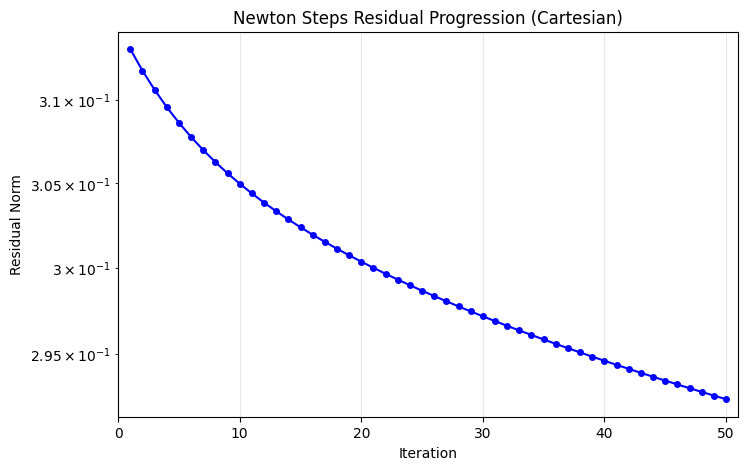

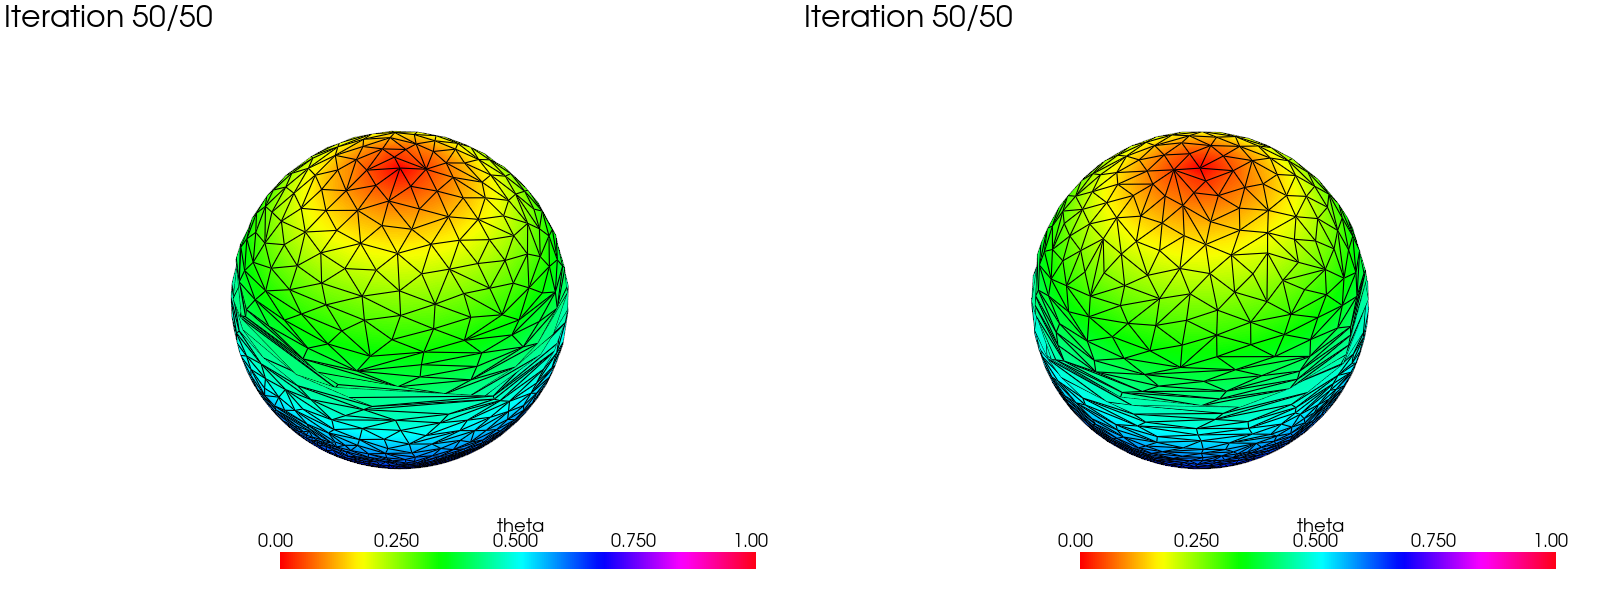

Iteration 50/50: Residual norm = 2.923910e-01


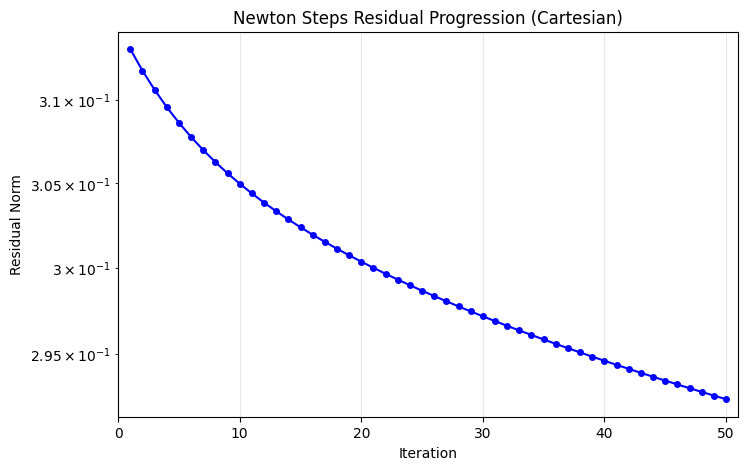

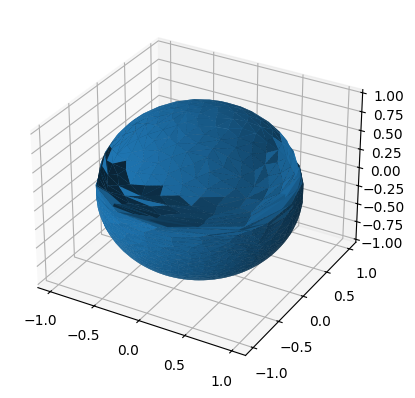


--- Full parameterized mesh: spherical normals check ---
  Faces checked (all vertices parameterized): 3994 / 4000
  Faces skipped (missing t,p): 6
  Outward (orient > 0): 3779
  Inward (orient < 0):  215
  Degenerate (|orient| < 1e-08): 0
  >>> INCONSISTENT: some normals inward, some outward (or degenerate).
      Spherical parameterization optimization / spherical harmonics may be invalid.
      Flipped face indices (first 20): [184, 190, 388, 393, 473, 474, 475, 477, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 495, 656] ...
---

After area optimization: theta=[0.0000, 3.1416]


In [14]:
# Step 1: Area optimization (method 1) on the full fine mesh
m_full_param.needs_mesh2sphere = 0  # already have initial t, p
m_full_param.optimization_method = 1
m_full_param.prevent_flip = True
m_full_param.newton_niter = 50
m_full_param.newton_step = 0.1
m_full_param.newton_step_edge = 0.05
m_full_param.bijective_plot_flag = 2
m_full_param.map2sphere()

from pySHP.level1.fix_flipped_faces import fix_spherical_parameterization_normals, check_spherical_parameterization_normals
m_full_param, _ = fix_spherical_parameterization_normals(m_full_param, verbose=True)
_ = check_spherical_parameterization_normals(m_full_param, verbose=True)
# Update X to spherical positions (optimization changed t, p)
from pySHP.utils import kk_sph2cart
u, v, w = kk_sph2cart(m_full_param.t, m_full_param.p, np.ones(len(m_full_param.t)))
m_full_param.X = np.column_stack([u, v, w])
print(f'After area optimization: theta=[{m_full_param.t.min():.4f}, {m_full_param.t.max():.4f}]')

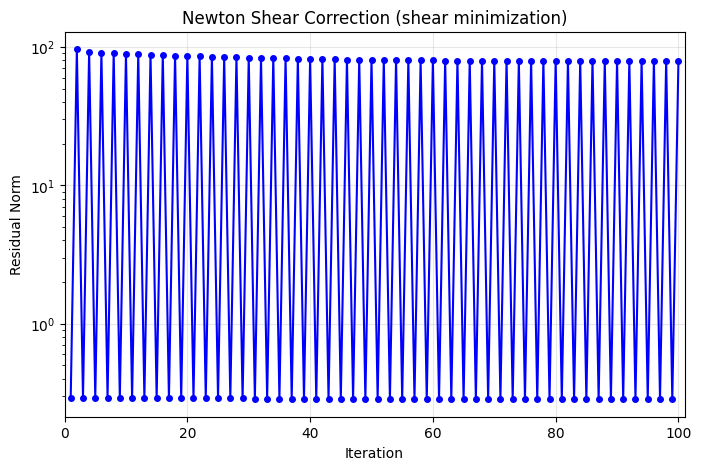

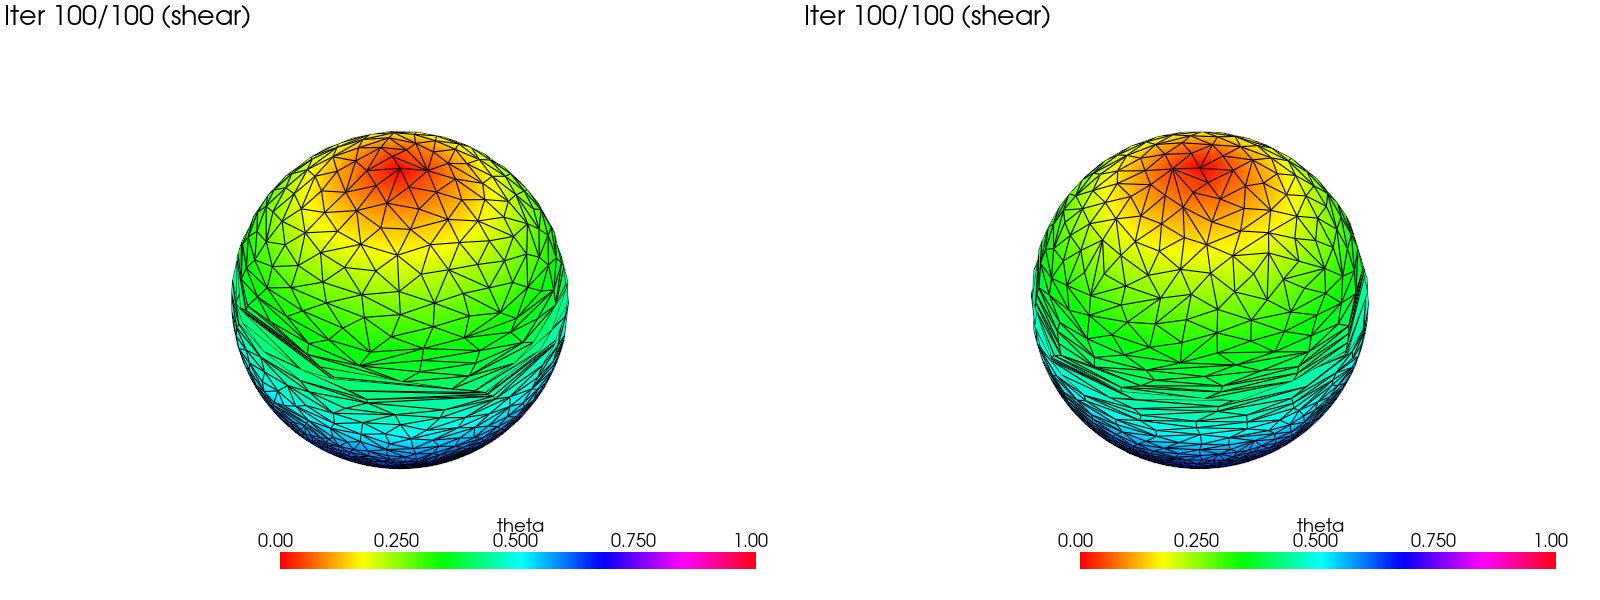

Iteration 100/100: Residual norm = 7.958056e+01 (shear)


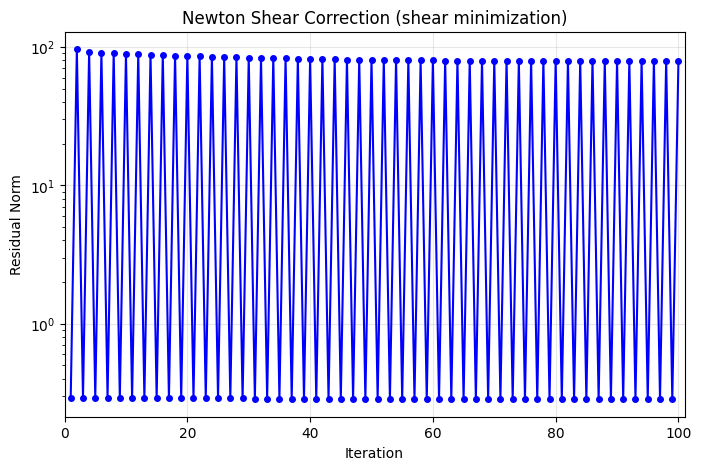

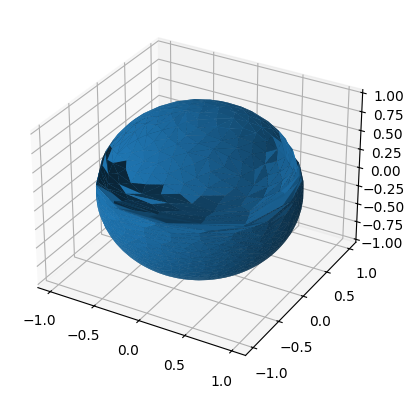


--- Full parameterized mesh: spherical normals check ---
  Faces checked (all vertices parameterized): 3994 / 4000
  Faces skipped (missing t,p): 6
  Outward (orient > 0): 3779
  Inward (orient < 0):  215
  Degenerate (|orient| < 1e-08): 0
  >>> INCONSISTENT: some normals inward, some outward (or degenerate).
      Spherical parameterization optimization / spherical harmonics may be invalid.
      Flipped face indices (first 20): [184, 190, 388, 393, 473, 474, 475, 477, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 495, 656] ...
---

After area+shear optimization: theta=[0.0000, 3.1416]


In [15]:
# Step 2: Area + shear optimization (method 2) on the full fine mesh
m_full_param.optimization_method = 2
m_full_param.prevent_flip = True
m_full_param.newton_niter = 100
m_full_param.newton_step = 0.2
m_full_param.bijective_plot_flag = 2
m_full_param.map2sphere()
m_full_param.needs_map2sphere = 0

from pySHP.level1.fix_flipped_faces import fix_spherical_parameterization_normals, check_spherical_parameterization_normals
m_full_param, _ = fix_spherical_parameterization_normals(m_full_param, verbose=True)
_ = check_spherical_parameterization_normals(m_full_param, verbose=True)
# Update X to spherical positions (optimization changed t, p)
from pySHP.utils import kk_sph2cart
u, v, w = kk_sph2cart(m_full_param.t, m_full_param.p, np.ones(len(m_full_param.t)))
m_full_param.X = np.column_stack([u, v, w])
print(f'After area+shear optimization: theta=[{m_full_param.t.min():.4f}, {m_full_param.t.max():.4f}]')

In [16]:
# Visualize optimized full fine-mesh parameterization
html_dir = os.path.join(code_dir, 'pySHP', 'tests', 'ddp_html')
os.makedirs(html_dir, exist_ok=True)
html_path = os.path.join(html_dir, 'full_fine_mesh_on_sphere_optimized.html')

m_full_param.plot_spherical_parameterization(flag=0, export_html_path=html_path)
print(f'Exported optimized parameterization: {html_path}')

# Export optimized mesh as .off
m_full_param.write_off('ddp_full_parameterized_mesh_optimized.off')
print('Exported: ddp_full_parameterized_mesh_optimized.off')

Exported full parameterization on sphere to: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\full_fine_mesh_on_sphere_optimized.html
Exported optimized parameterization: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\ddp_html\full_fine_mesh_on_sphere_optimized.html
Exported: ddp_full_parameterized_mesh_optimized.off


## 13. Spherical harmonics projection (on optimized fine mesh)

In [17]:
L_max = 8
s = shp_surface(m_full_param, L_max)
print(f'Spherical harmonics surface created:')
print(f'  L_max: {s.L_max}')
print(f'  Number of coefficients: {len(s.xc)}')
print(f'  Residual (reconstruction error): {np.linalg.norm(s.residual):.6e}')

output_filename = 'ddp_parameterized_mesh.shp3'
s.export_shp3(output_filename)
print(f'\nExported to: {output_filename}')

Spherical harmonics surface created:
  L_max: 8
  Number of coefficients: 81
  Residual (reconstruction error): 3.024602e+00
Exported spherical harmonics surface to: ddp_parameterized_mesh.shp3
  L_max: 8
  Number of coefficients: 81
  Components: 3 (x, y, z)

Exported to: ddp_parameterized_mesh.shp3


In [18]:
# Export to .shp3 file
s.export_shp3("parameterized_mesh.shp3")
print("Exported: parameterized_mesh.shp3")

# Reconstruct mesh from SHP coefficients and export as .off
mshp3, X_shp, F_shp, Y_LK, t_shp, p_shp = s.get_mesh(5)
mshp3.write_off("parameterized_shp3_mesh.off")
print(f"Exported SHP reconstruction: parameterized_shp3_mesh.off  ({len(mshp3.X)} verts, {len(mshp3.F)} faces)")

# Export the original parameterized fine mesh as .off
m_full_param.write_off("ddp_full_parameterized_mesh.off")
print("Exported original parameterized mesh: ddp_full_parameterized_mesh.off")


Exporting to .shp3 file...
Exported spherical harmonics surface to: parameterized_mesh.shp3
  L_max: 8
  Number of coefficients: 81
  Components: 3 (x, y, z)
Exported SHP reconstruction as: parameterized_shp3_mesh.off
  Vertices: 10242, Faces: 20480
Exported original parameterized mesh as: ddp_full_parameterized_mesh.off


In [19]:
# Plot the SHP reconstruction (must be in its own cell for PyVista static backend to render)
s.plot(nico=5)